In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

VIDEO_PATH  = "../data/subject1/vid.avi"
ROI_PATH    = "../outputs/roi_coords.npy"

roi_coords  = np.load(ROI_PATH)
cap         = cv2.VideoCapture(VIDEO_PATH)
fps         = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Loaded {len(roi_coords)} ROI boxes")
print(f"Video: {frame_count} frames @ {fps:.2f} fps")

Loaded 1547 ROI boxes
Video: 1547 frames @ 29.26 fps


In [9]:
R_signal = []
G_signal = []
B_signal = []

for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    x1, y1, x2, y2 = roi_coords[i]

    patch = frame_rgb[y1:y2, x1:x2]   # crop forehead

    R_signal.append(patch[:, :, 0].mean())
    G_signal.append(patch[:, :, 1].mean())
    B_signal.append(patch[:, :, 2].mean())

cap.release()

R_signal = np.array(R_signal)
G_signal = np.array(G_signal)
B_signal = np.array(B_signal)

t = np.arange(len(R_signal)) / fps

print("Extracted RGB signals ✓")
print(f"  R mean: {R_signal.mean():.2f}   G mean: {G_signal.mean():.2f}   B mean: {B_signal.mean():.2f}")


np.save("../outputs/R_signal.npy", R_signal)
np.save("../outputs/G_signal.npy", G_signal)
np.save("../outputs/B_signal.npy", B_signal)
print("Saved R, G, B signals ✓")

Extracted RGB signals ✓
  R mean: 186.91   G mean: 144.50   B mean: 141.58
Saved R, G, B signals ✓


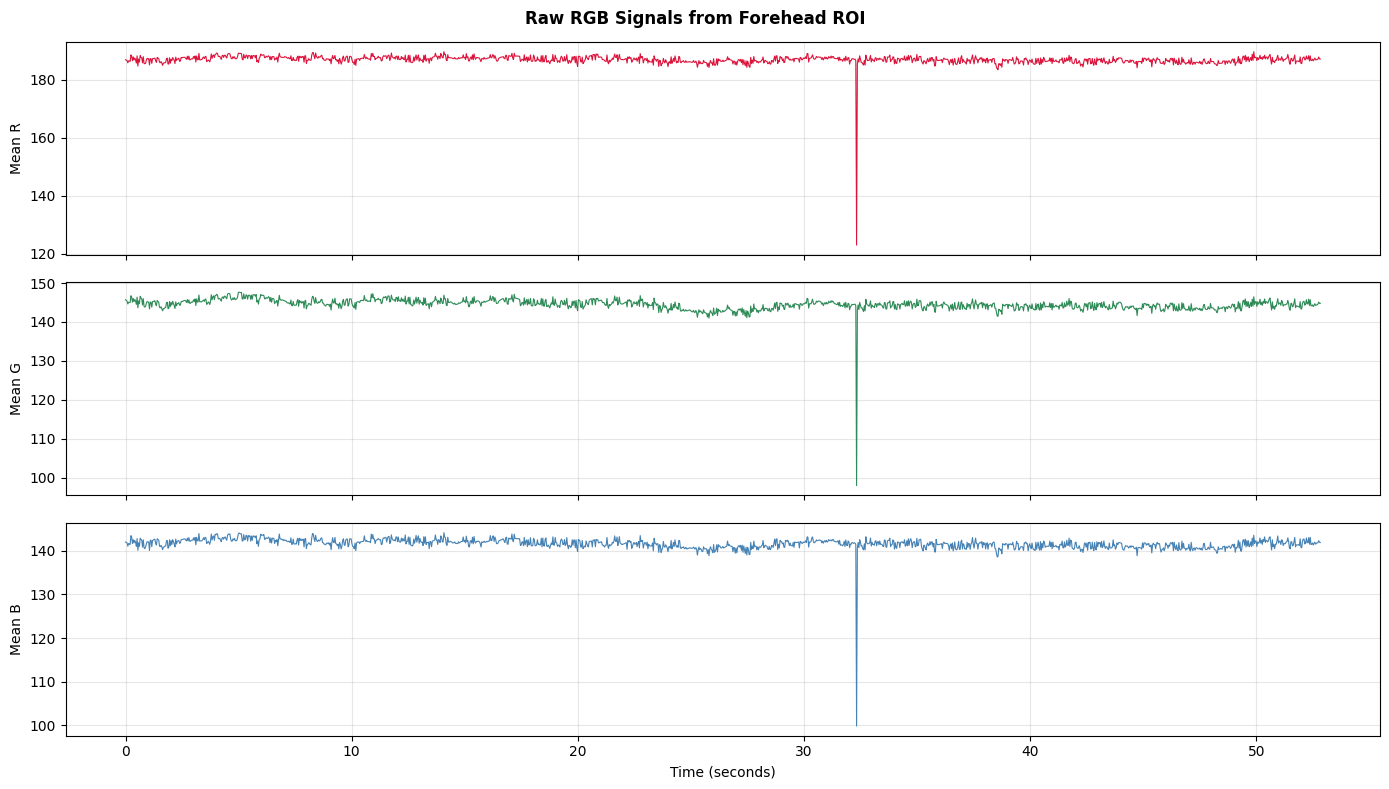

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Raw RGB Signals from Forehead ROI", fontweight='bold')

axes[0].plot(t, R_signal, color='crimson',   linewidth=0.8)
axes[0].set_ylabel("Mean R");  axes[0].grid(True, alpha=0.3)

axes[1].plot(t, G_signal, color='seagreen',  linewidth=0.8)
axes[1].set_ylabel("Mean G");  axes[1].grid(True, alpha=0.3)

axes[2].plot(t, B_signal, color='steelblue', linewidth=0.8)
axes[2].set_ylabel("Mean B");  axes[2].set_xlabel("Time (seconds)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/raw_rgb_signals.png", dpi=150)
plt.show()

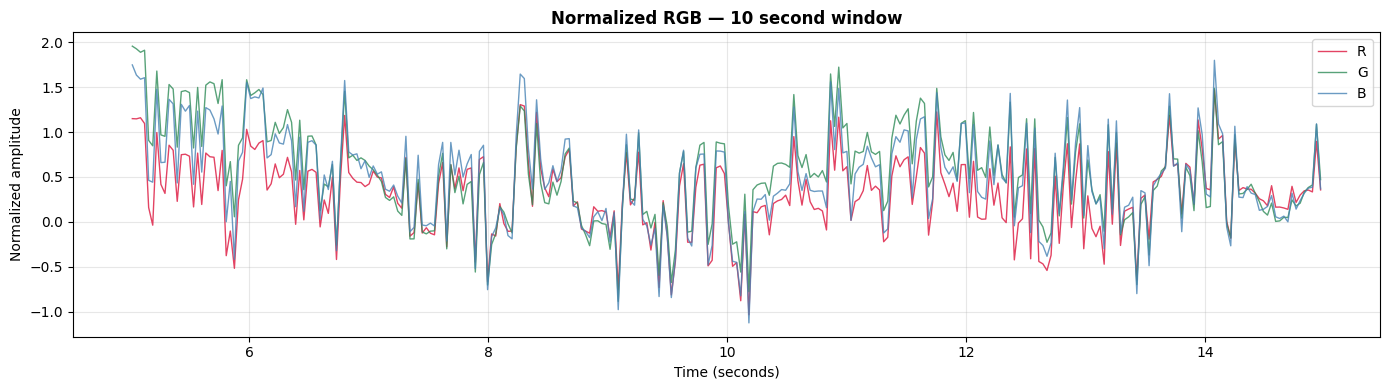

In [11]:
# Normalize each channel (zero mean, unit variance)
def normalize(sig):
    return (sig - sig.mean()) / sig.std()

R_norm = normalize(R_signal)
G_norm = normalize(G_signal)
B_norm = normalize(B_signal)

# Plot all three overlaid — zoomed to 10 seconds
mask = (t >= 5) & (t <= 15)

plt.figure(figsize=(14, 4))
plt.plot(t[mask], R_norm[mask], color='crimson',   linewidth=1.0, alpha=0.8, label='R')
plt.plot(t[mask], G_norm[mask], color='seagreen',  linewidth=1.0, alpha=0.8, label='G')
plt.plot(t[mask], B_norm[mask], color='steelblue', linewidth=1.0, alpha=0.8, label='B')
plt.title("Normalized RGB — 10 second window", fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/rgb_normalized_zoom.png", dpi=150)
plt.show()